# **Проект модуля. Нейросеть для автодополнения текстов.**


## **Этап 1.Сбор и подготовка данных**
1. Скачайте датасет, положите его в папку data.
    
2. «Почистите» тексты в датасете, а затем токенизируйте их. Для удобства можете сохранить почищенный и токенизированный датасет.

3. Разбейте датасет на трейн, валидацию и тест.
    
4. Создайте torch.Dataset и torch.DataLoader для обучения модели.

In [ ]:
import os

os.mkdir("data")

1. Неочищенный набор данных храниться в папке data и представлен двумя файлами - test_dataset_raw.csv, train_dataset_raw.csv

In [1]:
from src import download_and_extract

DATA_URL: str = "https://cs.stanford.edu/people/alecmgo/trainingandtestdata.zip"

data_path: str = "./data/"

download_and_extract(DATA_URL, data_path)

Скачивание архива...
Архив успешно скачан
Распаковка архива...
Архив успешно распакован в папку ./data/
Временный архив удален


2. Выполним очистку и токенизацию текста, сохранив результаты в clean_dataset.csv, clean_tokenized_dataset.csv в папке data

In [1]:
from src import preprocess_clean_dataset

input_file: str = "./data/training.1600000.processed.noemoticon.csv"
output_file: str = "./data/cleaned_dataset.csv"

# for train data
preprocess_clean_dataset(input_file, output_file)

Очищенные данные сохранены в ./data/cleaned_dataset.csv
Файл удален: ./data/training.1600000.processed.noemoticon.csv


In [2]:
# for test data
input_file = "./data/testdata.manual.2009.06.14.csv"
output_file = "./data/test_cleaned_dataset.csv"

preprocess_clean_dataset(input_file, output_file)

Очищенные данные сохранены в ./data/test_cleaned_dataset.csv
Файл удален: ./data/testdata.manual.2009.06.14.csv


Создадим токенизированный набор данных:

In [3]:
from src import save_tokenized_dataset

input_file = "./data/cleaned_dataset.csv"
output_file = "./data/dataset.csv"

save_tokenized_dataset(input_file, output_file)

Токенизированные данные сохранены в ./data/dataset.csv
Пример токенов: [101, 1037, 2008, 2015, 1037, 26352, 5017, 1012, 2017, 2323]...


In [1]:
from src import save_tokenized_dataset

input_file = "./data/test_cleaned_dataset.csv"
output_file = "./data/test.csv"

save_tokenized_dataset(input_file, output_file)

Токенизированные данные сохранены в ./data/test.csv
Пример токенов: [101, 1045, 8840, 9541, 9541, 9541, 4492, 2615, 2615, 2615]...


**3.Разделим данные на тренировочные и валидационные**

In [1]:
from src import split_dataset

input_file = "./data/dataset.csv"
train_file = "./data/train.csv"
val_file = "./data/val.csv"

split_dataset(input_file,
              train_file,
              val_file,
              val_size=0.1)

Train данных: 1437303
Val данных: 159701
Train сохранен в ./data/train.csv
Val сохранен в ./data/val.csv


Проанализируем набор данных для того, чтобы подобрать оптимальную длину последовательности:

=== СТАТИСТИКА ДЛИН ПОСЛЕДОВАТЕЛЬНОСТЕЙ ===
Общее количество последовательностей: 1437303
Средняя длина: 18.6
Медианная длина: 17.0
Минимальная длина: 3
Максимальная длина: 122
Стандартное отклонение: 9.1
25% перцентиль: 11.0
50% перцентиль: 17.0
75% перцентиль: 25.0
90% перцентиль: 32.0
95% перцентиль: 34.0
99% перцентиль: 40.0


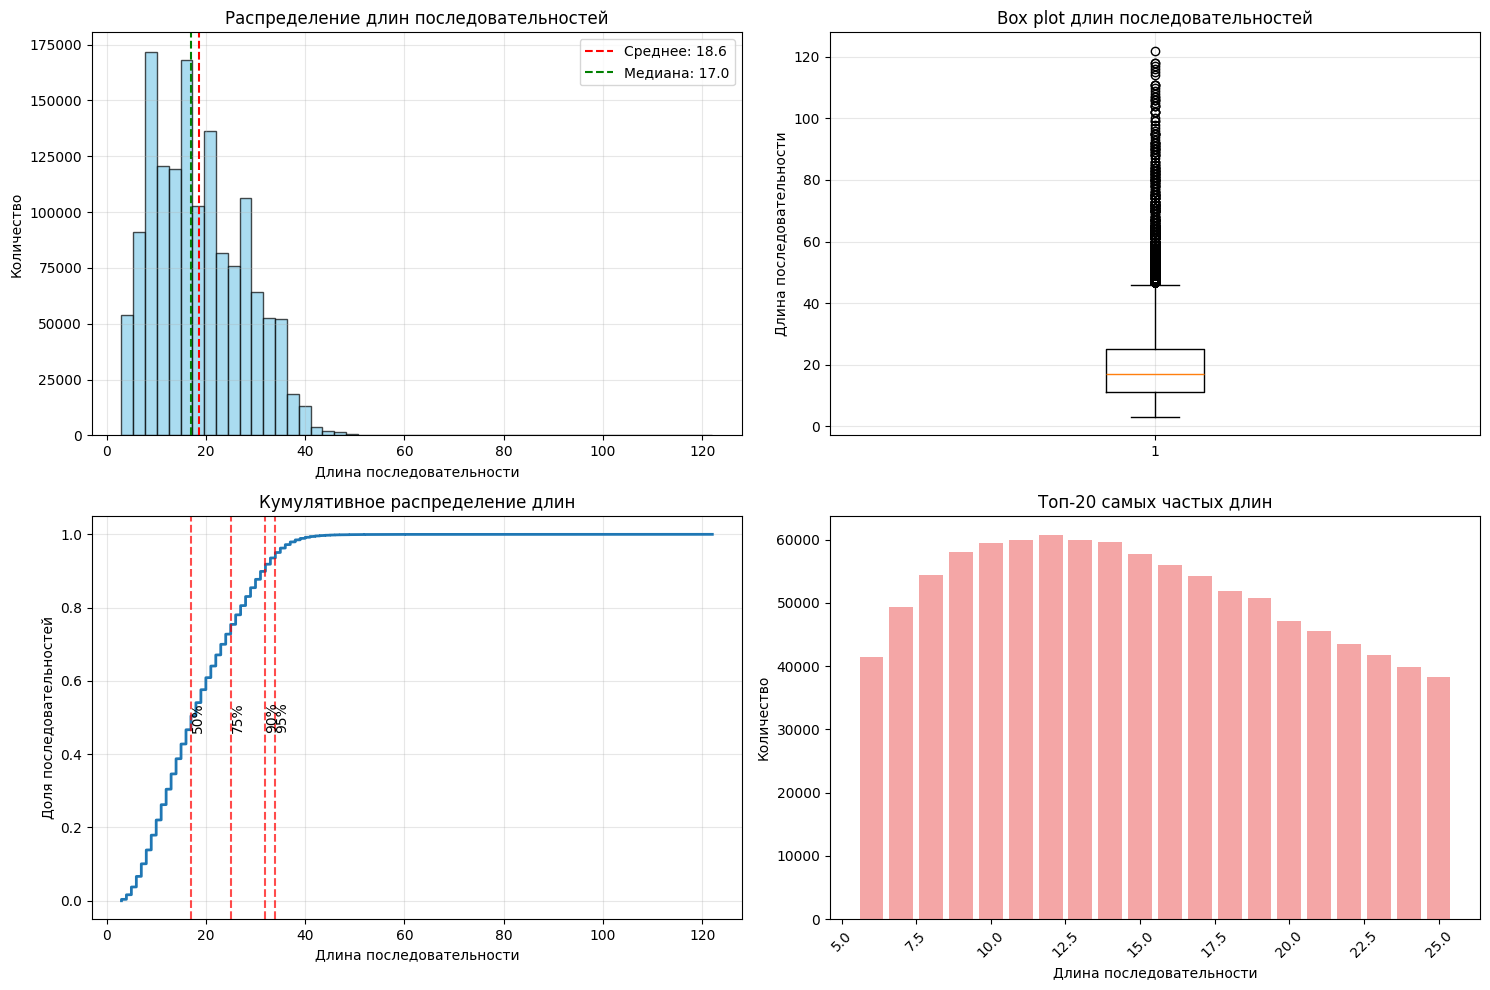


=== РЕКОМЕНДАЦИИ ПО ВЫБОРУ SEQUENCE_LENGTH ===
Покрытие данных для разных sequence_length:
sequence_length =   5:  98.4% данных (1413963 последовательностей)
sequence_length =  10:  82.1% данных (1180149 последовательностей)
sequence_length =  15:  61.3% данных (880391 последовательностей)
sequence_length =  20:  42.4% данных (609640 последовательностей)
sequence_length =  25:  27.3% данных (391699 последовательностей)
sequence_length =  30:  14.6% данных (209601 последовательностей)
sequence_length =  40:   1.1% данных (16093 последовательностей)
sequence_length =  50:   0.1% данных ( 1230 последовательностей)
sequence_length =  64:   0.0% данных (  217 последовательностей)
sequence_length = 128:   0.0% данных (    0 последовательностей)

Рекомендуемая sequence_length: 10
Это покроет 82.1% данных

При sequence_length = 10:
Будет потеряно 17.9% данных
Останется 1180149 последовательностей для обучения


In [1]:
from src import analyze_for_sequence

train_data: str = "./data/train.csv"

analyze_for_sequence(train_data)

In [3]:

from src import NextTokenDataset
from torch.utils.data import DataLoader

# Создаем dataset
dataset = NextTokenDataset(
    csv_file="./data/val.csv",  # val data
    sequence_length=7  # Длина контекста для предсказания
)

# Создаем DataLoader
dataloader = DataLoader(
    dataset,
    num_workers=4,
    persistent_workers=True,
    batch_size=64,
    shuffle=True)

# Проверяем данные
print("=== ПРОВЕРКА ДАТАСЕТА ===")
print(f"Всего примеров: {len(dataset)}")

# Несколько примеров
for i in range(3):
    sample_info = dataset.get_sample_info(i)
    print(f"\nПример {i}:")
    print(f"Input sequence: {sample_info['input_sequence'][:10]}...")  # Показываем первые 10 токенов
    print(f"Target token: {sample_info['target_token']}")
    print(f"Original text: {sample_info['original_text'][:100]}...")

# Проверяем батчи
print("\n=== ПРОВЕРКА БАТЧЕЙ ===")
for batch_idx, (inputs, targets) in enumerate(dataloader):
    print(f"Батч {batch_idx}:")
    print(f"  Inputs shape: {inputs.shape}")    # [32, sequence_length]
    print(f"  Targets shape: {targets.shape}")  # [32]
    
    if batch_idx >= 2:  # Показываем только первые 3 батча
        break

Создано 1869908 осмысленных примеров
=== ПРОВЕРКА ДАТАСЕТА ===
Всего примеров: 1869908

Пример 0:
Input sequence: [101, 7910, 2290, 2049, 17111, 9541, 7977]...
Target token: 4757
Original text: uhg its soooo grosssss and i wanted this to be a good weekend! well next weekend its of to wyomming ...

Пример 1:
Input sequence: [7910, 2290, 2049, 17111, 9541, 7977, 4757]...
Target token: 2015
Original text: uhg its soooo grosssss and i wanted this to be a good weekend! well next weekend its of to wyomming ...

Пример 2:
Input sequence: [2290, 2049, 17111, 9541, 7977, 4757, 2015]...
Target token: 1998
Original text: uhg its soooo grosssss and i wanted this to be a good weekend! well next weekend its of to wyomming ...

=== ПРОВЕРКА БАТЧЕЙ ===
Батч 0:
  Inputs shape: torch.Size([64, 7])
  Targets shape: torch.Size([64])
Батч 1:
  Inputs shape: torch.Size([64, 7])
  Targets shape: torch.Size([64])
Батч 2:
  Inputs shape: torch.Size([64, 7])
  Targets shape: torch.Size([64])


**4. Создадим torch.Dataset и torch.DataLoader**

In [ ]:
from src import NextTokenDataset
from torch.utils.data import DataLoader, SubsetRandomSampler

train_data = "./data/train.csv"
val_data = "./data/val.csv"
test_data = "./data/test.csv"

train_dataset = NextTokenDataset(
    train_data,
    sequence_length=7,
    min_sequence_length=10
)

# Для начала взглянем на работоспособность модели на 50000 данных
train_indices = list(range(min(50000, len(train_dataset))))

val_dataset = NextTokenDataset(
    val_data,
    sequence_length=7,
    min_sequence_length=10
)

train_loader = DataLoader(
    train_dataset,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    batch_size=128,
    sampler=SubsetRandomSampler(train_indices),
    prefetch_factor=2)